In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
import pandas as pd

In [28]:
df=pd.read_csv("../datasets/dataset_to_train_V01.csv")

In [29]:
df.head()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,ax,ay,az,gx,gy,gz,label
0,0,0,0,0,24,15,44,45,-0.23,0.91,0.32,0,3,0,char
1,0,0,0,0,14,10,51,38,-0.23,0.91,0.33,-2,3,0,char
2,0,0,0,0,8,7,52,31,-0.23,0.91,0.33,0,3,0,char
3,0,0,0,0,0,2,49,28,-0.23,0.91,0.33,0,3,1,char
4,0,0,0,0,0,0,52,25,-0.23,0.92,0.33,0,3,1,char


In [31]:
df['label'] = df['label'].replace({'ka': 0,'kha': 1,'ga' : 2,'gha' : 3,'nga' : 4,'ek' : 5,'dui' : 6,'tin' : 7,'char' : 8})

In [32]:
df.head()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,ax,ay,az,gx,gy,gz,label
0,0,0,0,0,24,15,44,45,-0.23,0.91,0.32,0,3,0,8
1,0,0,0,0,14,10,51,38,-0.23,0.91,0.33,-2,3,0,8
2,0,0,0,0,8,7,52,31,-0.23,0.91,0.33,0,3,0,8
3,0,0,0,0,0,2,49,28,-0.23,0.91,0.33,0,3,1,8
4,0,0,0,0,0,0,52,25,-0.23,0.92,0.33,0,3,1,8


In [33]:
df.tail()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,ax,ay,az,gx,gy,gz,label
4495,0,0,0,0,0,0,13,40,-0.21,0.89,0.38,-2,3,0,7
4496,0,0,0,0,0,0,13,40,-0.22,0.90,0.37,-2,3,-1,7
4497,0,0,0,0,0,0,13,38,-0.22,0.90,0.37,-2,3,0,7
4498,0,0,0,0,0,0,13,38,-0.22,0.90,0.38,-3,3,0,7
4499,0,0,0,0,0,0,11,38,-0.21,0.90,0.39,-3,2,0,7


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test= train_test_split(df.drop(['label'],axis='columns'),df['label'],test_size=0.3)

In [36]:
len(x_train)

3150

In [38]:
x_train

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,ax,ay,az,gx,gy,gz
1365,0,0,137,66,53,14,32,63,-0.34,0.84,0.41,-1,2,-1
3725,82,11,138,92,37,16,0,0,-0.91,0.31,0.16,-2,1,0
1760,51,0,138,60,40,15,39,63,-0.11,0.93,0.36,-15,20,2
2994,0,8,117,91,28,24,11,63,-0.04,0.95,0.26,-2,3,0
4266,0,0,0,0,0,0,3,52,-0.25,0.89,0.37,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,0,0,0,0,0,0,6,48,-0.25,0.88,0.38,-1,2,0
1048,0,0,136,65,54,17,40,80,-0.40,0.81,0.44,2,-7,4
3605,57,10,140,89,67,12,0,0,-0.92,0.31,0.12,0,14,3
1457,0,0,135,64,42,14,46,67,-0.26,0.87,0.37,0,2,-1


In [39]:
x_test

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,ax,ay,az,gx,gy,gz
472,0,0,0,0,0,0,40,0,-0.14,0.96,0.11,-2,2,0
2437,0,0,0,0,0,0,46,0,-0.96,0.11,0.15,0,3,0
1690,67,0,135,58,37,15,29,62,-0.15,0.94,0.28,-11,2,-3
3659,64,14,136,93,61,21,0,0,-0.90,0.33,0.14,-1,1,-2
621,0,0,0,0,45,3,15,80,-0.30,0.87,0.37,-2,4,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4191,0,0,0,0,0,0,15,52,-0.25,0.89,0.39,-3,2,0
4426,0,0,0,0,0,0,22,47,-0.21,0.88,0.42,-2,3,1
4215,0,0,0,0,0,0,8,47,-0.26,0.88,0.37,-1,2,-2
85,0,0,0,0,0,0,52,0,-0.18,0.95,0.14,0,1,0


In [40]:
y_test

472     8
2437    3
1690    2
3659    4
621     6
       ..
4191    7
4426    7
4215    7
85      8
3771    4
Name: label, Length: 1350, dtype: int64

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
model=RandomForestClassifier(n_estimators=50)

In [43]:
model.fit(x_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
model.score(x_test,y_test)

1.0

In [45]:
y_predicted=model.predict(x_test)

In [46]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predicted)
cm

array([[139,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 164,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0, 145,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 147,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 142,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 151,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 152,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 156,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 154]])

Text(0.5, 1.0, 'Confusion Matrix')

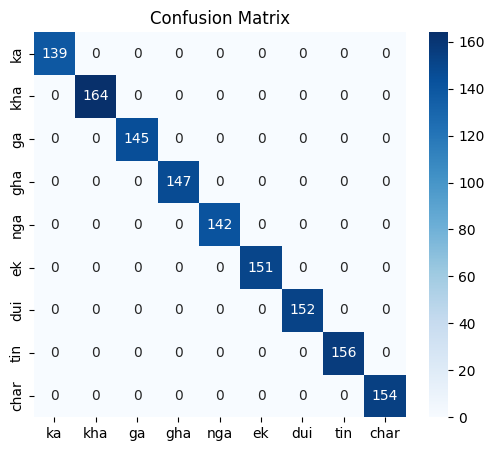

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sm
import numpy as np
plt.figure(figsize=(6,5))
labels = ['ka', 'kha', 'ga', 'gha','nga', 'ek', 'dui', 'tin', 'char']
sm.heatmap(cm,annot=True,fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel=('predicted')
plt.ylabel=('Truth')
plt.title('Confusion Matrix')


In [23]:
train_accuracy = model.score(x_train, y_train) * 100
test_accuracy  = model.score(x_test, y_test) * 100
print(f"Train Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Train Accuracy: 100.00%
Test Accuracy: 100.00%


In [48]:
import joblib

joblib.dump(model, "../models(joblib)/Gesture_Model.joblib")
print("Model saved as Gesture_Model.joblib")

Model saved as Gesture_Model.joblib


TypeError: 'str' object is not callable

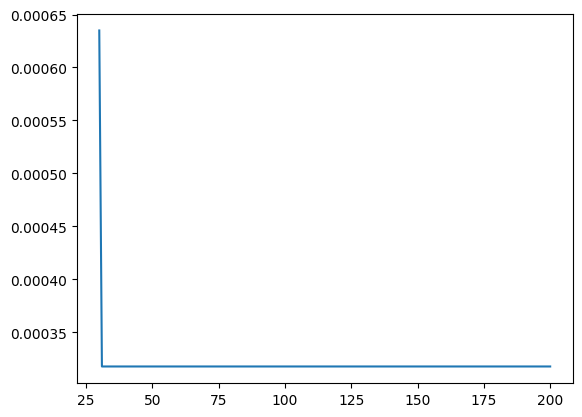

In [25]:


rf = RandomForestClassifier(
    n_estimators=30,      # start with enough trees
    oob_score=True,
    warm_start=True,
    bootstrap=True
)

oob_errors = []

for i in range(30, 201):  # from 30 to 200 trees
    rf.n_estimators = i
    rf.fit(x_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.plot(range(30, 201), oob_errors)
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Curve")
plt.show()


TypeError: 'str' object is not callable

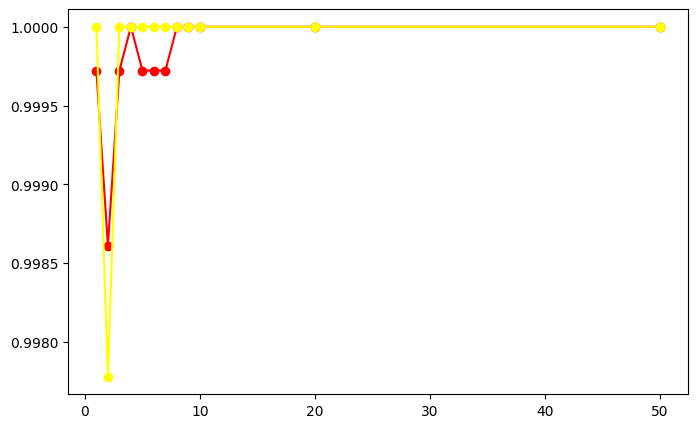

In [26]:

from sklearn.metrics import accuracy_score

# Example dataset (replace with your own data)
# X = ...
# y = ...

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
   df.drop(['label'],axis='columns'),df['label'], test_size=0.2, random_state=42
)

# Range of tree counts
n_estimators_list = [1,2,3,4,5,6,7,8,9,10, 20, 50]

train_acc = []
test_acc = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))


# Plot accuracy curve
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, train_acc, marker='o', label="Train Accuracy",color='red')
plt.plot(n_estimators_list, test_acc, marker='o', label="Test Accuracy",color='yellow')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()



Total records loaded: 6000
Dataset shape: (6000, 60, 15)
Labels found: {'malai', 'ramro', 'namaste', 'day', 'chinnu', 'today'}

Classes:
['chinnu' 'day' 'malai' 'namaste' 'ramro' 'today']

Train shape: (4800, 60, 15)
Test shape : (1200, 60, 15)


/home/sanjog/Documents/major_project/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,150 (133.40 KB)

 Trainable params: 34,150 (133.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.8760 - loss: 0.3850 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 2/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9998 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 3.8663e-04
Epoch 4/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.8719e-04
Epoch 5/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.9396 - loss: 0.1822 - val_accuracy: 0.9925 - val_loss: 0.1503
Epoch 6/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.9915 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 3.4461e-04
Epoch 8/80
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - accuracy: 1.0000 - los

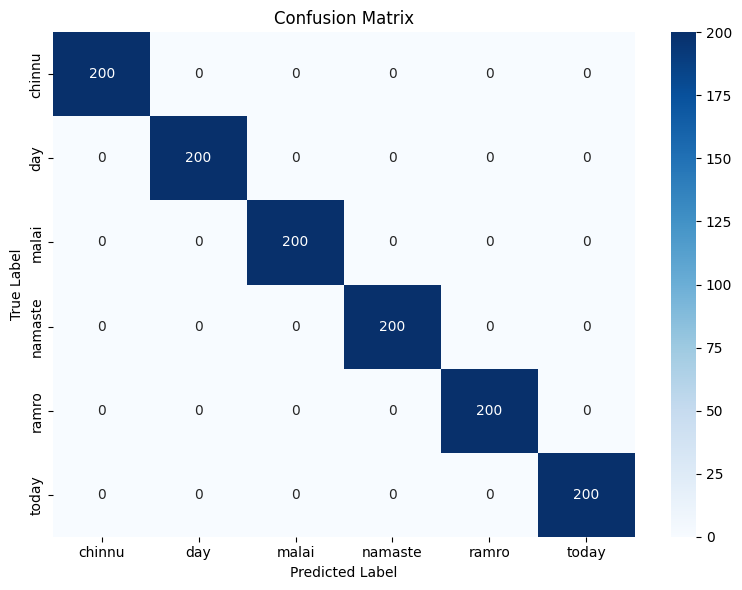

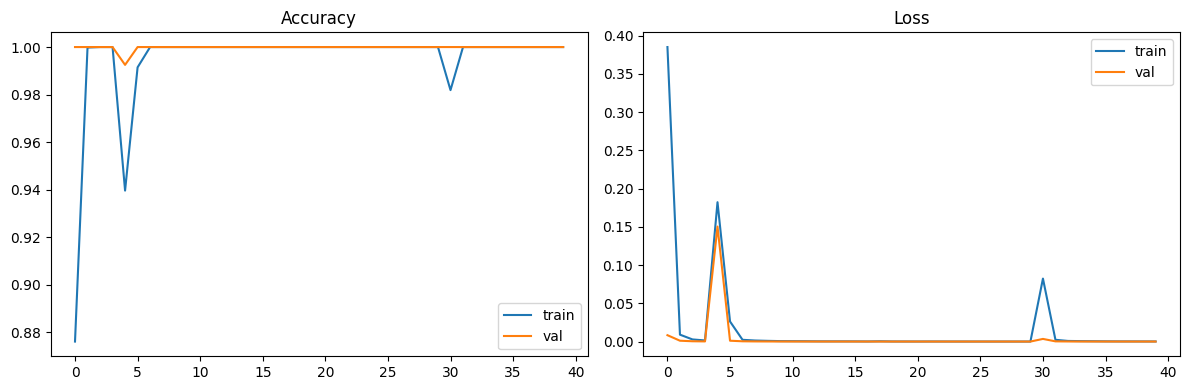


Model saved to gesture_model.h5
Scaler saved to scaler.pkl
Label encoder saved to label_encoder.pkl


In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import pickle

# ── CONFIG ─────────────────────────────────────────────────────────────────────
DATA_DIR      = "../JSON_AUGMENTED"
TARGET_LENGTH = 60
TEST_SIZE     = 0.2
EPOCHS        = 80
BATCH_SIZE    = 16

# ── FEATURE EXTRACTION ─────────────────────────────────────────────────────────
# 15 features total:
# 8 flex + 3 accel + 3 gyro + 1 normalized timestamp

def extract_features(samples):
    """
    Convert sample list into (T x 15) feature array.
    Includes normalized timestamp as final feature.
    """

    rows = []

    timestamps = [s["timestamp"] for s in samples]

    t_min = min(timestamps)
    t_max = max(timestamps)
    t_range = t_max - t_min

    for i, (s, t) in enumerate(zip(samples, timestamps)):

        # Normalized time feature (0 → 1)
        t_norm = (
            (t - t_min) / t_range
            if t_range > 0
            else i / max(len(samples) - 1, 1)
        )

        rows.append([
            s["flex"]["index_upper"],
            s["flex"]["index_lower"],
            s["flex"]["middle_upper"],
            s["flex"]["middle_lower"],
            s["flex"]["ring_upper"],
            s["flex"]["ring_lower"],
            s["flex"]["thumb"],
            s["flex"]["pinky"],

            s["accel"]["x"],
            s["accel"]["y"],
            s["accel"]["z"],

            s["gyro"]["x"],
            s["gyro"]["y"],
            s["gyro"]["z"],

            t_norm      # 15th feature
        ])

    return np.array(rows, dtype=np.float32)


def resample_sequence(seq, target_length):
    """
    Resample (T x F) → (target_length x F)
    """

    T, F = seq.shape

    if T == target_length:
        return seq

    x_old = np.linspace(0, 1, T)
    x_new = np.linspace(0, 1, target_length)

    resampled = np.zeros((target_length, F), dtype=np.float32)

    for f in range(F):
        interp = interp1d(
            x_old,
            seq[:, f],
            kind="linear"
        )
        resampled[:, f] = interp(x_new)

    return resampled


# ── LOAD DATA ──────────────────────────────────────────────────────────────────
X_raw = []
y_raw = []

for filename in os.listdir(DATA_DIR):

    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(DATA_DIR, filename)

    with open(filepath, "r") as f:
        records = json.load(f)

    for record in records:

        label   = record["gesture_label"]
        samples = record["samples"]

        if len(samples) < 5:
            print(f"Skipping short record in {filename}")
            continue

        features = extract_features(samples)

        resampled = resample_sequence(
            features,
            TARGET_LENGTH
        )

        X_raw.append(resampled)
        y_raw.append(label)

# Convert to numpy
X = np.array(X_raw, dtype=np.float32)

print(f"\nTotal records loaded: {len(X)}")
print(f"Dataset shape: {X.shape}")
print(f"Labels found: {set(y_raw)}")

# Expected shape:
# (N, 50, 15)

# ── NORMALIZATION ──────────────────────────────────────────────────────────────
N, T, F = X.shape

X_2d = X.reshape(-1, F)

scaler = MinMaxScaler()

X_2d_scaled = scaler.fit_transform(X_2d)

X_scaled = X_2d_scaled.reshape(N, T, F)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# ── LABEL ENCODING ─────────────────────────────────────────────────────────────
le = LabelEncoder()

y_encoded = le.fit_transform(y_raw)

y_onehot = to_categorical(y_encoded)

num_classes = len(le.classes_)

print(f"\nClasses:")
print(le.classes_)

# Save encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# ── TRAIN / TEST SPLIT ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_onehot,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

# ── BUILD MODEL ────────────────────────────────────────────────────────────────
model = Sequential([

    LSTM(
        64,
        input_shape=(TARGET_LENGTH, F),
        return_sequences=True
    ),

    Dropout(0.3),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ── TRAIN ──────────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

# ── EVALUATE ───────────────────────────────────────────────────────────────────
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"\nTest Accuracy: {acc * 100:.2f}%")

# Predictions
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=le.classes_
))

# ── CONFUSION MATRIX ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# ── TRAINING CURVES ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="val")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="val")
ax2.set_title("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

# ── SAVE MODEL ─────────────────────────────────────────────────────────────────
model.save("gesture_model.h5")

print("\nModel saved to gesture_model.h5")
print("Scaler saved to scaler.pkl")
print("Label encoder saved to label_encoder.pkl")